In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))
from ISP_tools.ProxyISPDataset import ProxyISPDataset, EXPERIMENT_OUTPUT_PATH
from model import U_Net
import matplotlib.pyplot as plt
import torch
import random
import yaml
import numpy as np
from pathlib import Path
import torch
import os
import copy
import glob
from proxy_utils import convert_color_space, extract_iteration
train_config_path = "/home/boat/proxyISP/ProxyOpt/train_configs/v16.2-chroma-HumanTunedInitialHype.yaml";
additional_conf = {
    "target_image": [str(i) for i in Path("/mnt/ssd2tb/boat/thesis/robocat_singleim").rglob("*.dng")]
}

with open(train_config_path, "r") as f:
    yaml_dict = yaml.safe_load(f)

config = yaml_dict["config"]
openisp_config = yaml_dict["openisp_config"]
hyp_setting = yaml_dict["hyp_setting"]

output_dir = EXPERIMENT_OUTPUT_PATH / config["experiment_name"]

checkpoint_files = os.listdir(output_dir / "checkpoints")

latest_file = max(checkpoint_files, key=lambda f: extract_iteration(f))

print("loading", latest_file)
latest_obj = torch.load(output_dir / "checkpoints" / latest_file)

config = latest_obj["config"]

in_channels = 1
if config["input_type"] == "stacked": in_channels = 4 #grgb

dataset = ProxyISPDataset(config, openisp_config, hyp_setting, additional_conf = additional_conf)
dataset.set_image_target_size([1920, 1920])

raw ,_ ,sample_hyp = dataset.__getitem__(0)
param_number = sample_hyp.shape[-1]

net = U_Net(in_channels, 3, step_flag=1, img_size=config["img_size"], param_number = param_number)
net.load_state_dict(latest_obj["model_state_dict"])
net = net.to("cuda")
for parameter in net.parameters():
    parameter.requires_grad = False

/tmp/ipykernel_417284/3314625067.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


/tmp/ipykernel_417284/3314625067.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  latest_obj = torch.load(output_dir / "checkpoints" / latest_file)
[11-01 17:58:50] Prox

loading checkpoint_2805000.pt


[11-01 17:58:51] ProxyISPDataset.py INFO - hyperp length: 50000
[11-01 17:58:51] ProxyISPDataset.py INFO - num_hyperp x num_image: 50000
[11-01 17:58:51] ProxyISPDataset.py INFO - total dataset length: 50000
[11-01 17:58:51] ProxyISPDataset.py INFO - processing /mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng with hyp [0, 1, 468, 2.2952052862943955, 48, 329, 4, 83, 61, 243, 2, 6, 33, 96, 38, 1785, -724, -158, 121, 1472, -379, -132, -768, 1893]
[11-01 17:58:51] s21fe_utils.py INFO - Raw, offsetX, offsetY, RandomX, RandomY, Cropped: (3000, 4000) 2080 1080 682 538 [1920, 1920]


/mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng
Executing awb... Done. Elapsed 0.015s
Executing cfa... Done. Elapsed 0.086s
Executing ccm... Done. Elapsed 0.111s
Executing gac... Done. Elapsed 0.053s
Executing bnfcv... Done. Elapsed 0.032s
Executing csc... Done. Elapsed 0.099s
Executing eeh... Done. Elapsed 0.151s
Executing hsc... Done. Elapsed 0.064s
Executing bcc... Done. Elapsed 0.024s
Pipeline elapsed 0.764s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])


Inference From Hype

In [2]:
# import pickle
# import torch
# with open("/home/boat/proxyISP/pytorch-superpoint/logs/PRETRAINED_SAMEMODELHOMOADAPT_AGGRESSIVEHOMOADAPT_train_v16.2-chroma-HumanTunedInitialHype_hpatchesv4_lr0.01_bothLoss_initialHypeHomoAdaptOnly_gradac8/proxyopt_checkpoints/checkpoint_67300.pkl", "rb") as f:
#     normalized_hyp = pickle.load(f)["proxy_hype"]
#     normalized_hyp = torch.tensor(normalized_hyp)
# normalized_hyp = torch.tensor([5.3999013e-01 9.8000008e-01 7.6005048e-01 4.7588310e-01 2.9335147e-01
#  9.8000014e-01 4.9999999e-06 1.0004991e-02 9.8000073e-01 7.4109083e-01
#  1.0004881e-02 1.0004925e-02 2.1661386e-01 2.4004336e-01 8.0060178e-01
#  2.3798557e-01 1.0000000e+00 1.0000000e+00 8.9999712e-01 2.0001905e-01
#  5.4034901e-01 9.9000013e-01 1.5011752e-01 1.0000000e+00])
normalized_hyp = torch.tensor([
    5.3999013e-01, 9.8000008e-01, 7.6005048e-01, 4.7588310e-01, 2.9335147e-01,
    9.8000014e-01, 4.9999999e-06, 1.0004991e-02, 9.8000073e-01, 7.4109083e-01,
    1.0004881e-02, 1.0004925e-02, 2.1661386e-01, 2.4004336e-01, 8.0060178e-01,
    2.3798557e-01, 1.0000000e+00, 1.0000000e+00, 8.9999712e-01, 2.0001905e-01,
    5.4034901e-01, 9.9000013e-01, 1.5011752e-01, 1.0000000e+00
])

# normalized_hyp = torch.ones([24])

denormalized_hype = dataset.denormalize_hyp(normalized_hyp.numpy())
denormalized_hype = torch.tensor(denormalized_hype)
print("denormalized_hype", denormalized_hype)
normalize_again = dataset.normalize_hyp(denormalized_hype).type(torch.float32)
print("normalize again", normalize_again)

net.load_param_layer(normalized_hyp)

24 24
denormalized_hype tensor([ 0.0000e+00,  1.0000e+00,  1.1400e+03,  1.4801e+00,  4.4000e+01,
         6.8600e+02,  1.0000e+00,  2.0000e+00,  9.8000e+01,  7.4100e+02,
         1.0000e+00,  1.0000e+00,  2.2000e+01,  4.3000e+01,  4.1000e+02,
         1.4790e+03, -3.3500e+02,  2.5800e+02,  7.1000e+01,  1.1380e+03,
        -1.1300e+02,  2.9200e+02, -9.0900e+02,  1.9680e+03],
       dtype=torch.float64)
normalize again tensor([0.0000, 1.0000, 0.7600, 0.4759, 0.2933, 0.9800, 0.0000, 0.0101, 0.9798,
        0.7410, 0.0000, 0.0000, 0.2121, 0.2402, 0.8008, 0.2383, 1.0000, 1.0000,
        0.9004, 0.1992, 0.5410, 0.9902, 0.1504, 1.0000])
self.param_layer.shape torch.Size([24])


In [3]:
normalized_hyp = normalized_hyp.to("cuda")
normalize_again = normalize_again.to("cuda")
normalized_hyp

tensor([5.3999e-01, 9.8000e-01, 7.6005e-01, 4.7588e-01, 2.9335e-01, 9.8000e-01,
        5.0000e-06, 1.0005e-02, 9.8000e-01, 7.4109e-01, 1.0005e-02, 1.0005e-02,
        2.1661e-01, 2.4004e-01, 8.0060e-01, 2.3799e-01, 1.0000e+00, 1.0000e+00,
        9.0000e-01, 2.0002e-01, 5.4035e-01, 9.9000e-01, 1.5012e-01, 1.0000e+00],
       device='cuda:0')

In [4]:
net.param_layer

tensor([5.3999e-01, 9.8000e-01, 7.6005e-01, 4.7588e-01, 2.9335e-01, 9.8000e-01,
        5.0000e-06, 1.0005e-02, 9.8000e-01, 7.4109e-01, 1.0005e-02, 1.0005e-02,
        2.1661e-01, 2.4004e-01, 8.0060e-01, 2.3799e-01, 1.0000e+00, 1.0000e+00,
        9.0000e-01, 2.0002e-01, 5.4035e-01, 9.9000e-01, 1.5012e-01, 1.0000e+00],
       device='cuda:0')

In [6]:
dataset.get_categorical_ids()

[(0, 1)]

In [79]:
hyp

tensor([0.0000, 1.0000, 0.7600, 0.4759, 0.2933, 0.9800, 0.0000, 0.0101, 0.9798,
        0.7410, 0.0000, 0.0000, 0.2121, 0.2402, 0.8008, 0.2383, 1.0000, 1.0000,
        0.9004, 0.1992, 0.5410, 0.9902, 0.1504, 1.0000], device='cuda:0')

In [99]:
normalized_hyp_mod = normalized_hyp
normalized_hyp_mod[0] = 0.0000
normalized_hyp_mod[1] = 1.0000
normalized_hyp_mod
normalized_hyp_mod[0] = 5.3999e-01
normalized_hyp_mod[1] = 9.8000e-01

[11-01 17:21:30] ProxyISPDataset.py INFO - processing /mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng with hyp [0, 1, 1140, 1.4800609797239304, 44, 686, 1, 2, 98, 741, 1, 1, 22, 43, 410, 1479, -335, 258, 71, 1138, -113, 292, -909, 1968]
[11-01 17:21:30] s21fe_utils.py INFO - Raw, offsetX, offsetY, RandomX, RandomY, Cropped: (3000, 4000) 2080 1080 1950 72 [1920, 1920]


24 24
denormalize hyp [0, 1, 1140, 1.4800609797239304, 44, 686, 1, 2, 98, 741, 1, 1, 22, 43, 410, 1479, -335, 258, 71, 1138, -113, 292, -909, 1968]
/mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng
Executing awb... Done. Elapsed 0.021s
Executing cfa... Done. Elapsed 0.093s
Executing ccm... Done. Elapsed 0.140s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.031s
Executing csc... Done. Elapsed 0.109s
Executing eeh... Done. Elapsed 0.151s
Executing hsc... Done. Elapsed 0.065s
Executing bcc... Done. Elapsed 0.018s
Pipeline elapsed 0.824s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
tensor([0.0000, 1.0000, 0.7600, 0.4759, 0.2933, 0.9800, 0.0000, 0.0101, 0.9798,
        0.7410, 0.0000, 0.0000, 0.2121, 0.2402, 0.8008, 0.2383, 1.0000, 1.0000,
        0.9004, 0.1992, 0.5410, 0.9902, 0.1504, 1.0000], device='cuda:0')
param_layer tensor([[[[0.5400, 0.5400, 0.5400,  ..., 0.5400, 0.5400, 0.5400],
          [0.5400, 0.5400, 0.5400,  ..., 0.5400, 0.5400, 0.5400]

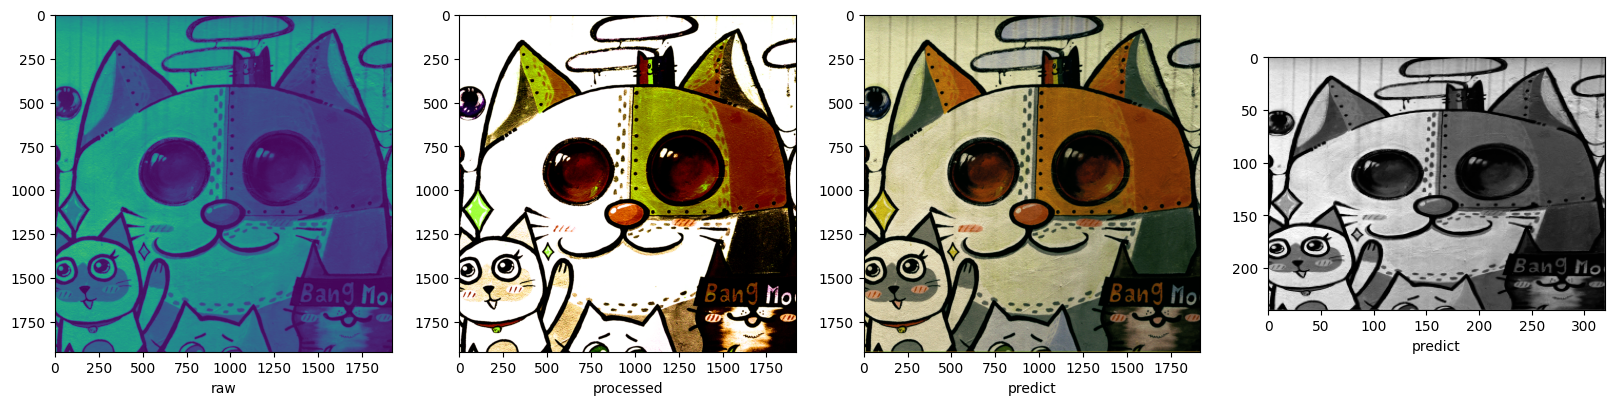

[11-01 17:21:32] ProxyISPDataset.py INFO - processing /mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng with hyp [0, 1, 1140, 1.4800609797239304, 44, 686, 1, 2, 98, 741, 1, 1, 22, 43, 410, 1479, -335, 258, 71, 1138, -113, 292, -909, 1968]
[11-01 17:21:32] s21fe_utils.py INFO - Raw, offsetX, offsetY, RandomX, RandomY, Cropped: (3000, 4000) 2080 1080 1646 702 [1920, 1920]


24 24
denormalize hyp [0, 1, 1140, 1.4800609797239304, 44, 686, 1, 2, 98, 741, 1, 1, 22, 43, 410, 1479, -335, 258, 71, 1138, -113, 292, -909, 1968]
/mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng
Executing awb... Done. Elapsed 0.015s
Executing cfa... Done. Elapsed 0.072s
Executing ccm... Done. Elapsed 0.139s
Executing gac... Done. Elapsed 0.049s
Executing bnfcv... Done. Elapsed 0.030s
Executing csc... Done. Elapsed 0.120s
Executing eeh... Done. Elapsed 0.149s
Executing hsc... Done. Elapsed 0.065s
Executing bcc... Done. Elapsed 0.025s
Pipeline elapsed 0.811s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
tensor([0.0000, 1.0000, 0.7600, 0.4759, 0.2933, 0.9800, 0.0000, 0.0101, 0.9798,
        0.7410, 0.0000, 0.0000, 0.2121, 0.2402, 0.8008, 0.2383, 1.0000, 1.0000,
        0.9004, 0.1992, 0.5410, 0.9902, 0.1504, 1.0000], device='cuda:0')
param_layer tensor([[[[0.5400, 0.5400, 0.5400,  ..., 0.5400, 0.5400, 0.5400],
          [0.5400, 0.5400, 0.5400,  ..., 0.5400, 0.5400, 0.5400]

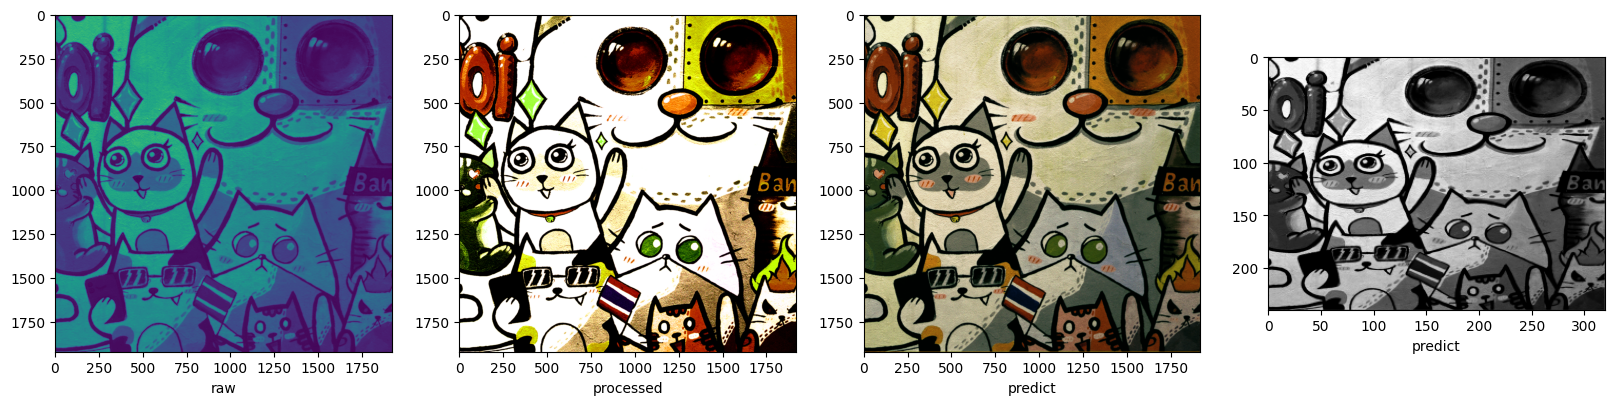

[11-01 17:21:34] ProxyISPDataset.py INFO - processing /mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng with hyp [0, 1, 1140, 1.4800609797239304, 44, 686, 1, 2, 98, 741, 1, 1, 22, 43, 410, 1479, -335, 258, 71, 1138, -113, 292, -909, 1968]
[11-01 17:21:34] s21fe_utils.py INFO - Raw, offsetX, offsetY, RandomX, RandomY, Cropped: (3000, 4000) 2080 1080 1202 246 [1920, 1920]


24 24
denormalize hyp [0, 1, 1140, 1.4800609797239304, 44, 686, 1, 2, 98, 741, 1, 1, 22, 43, 410, 1479, -335, 258, 71, 1138, -113, 292, -909, 1968]
/mnt/ssd2tb/boat/thesis/robocat_singleim/1.dng
Executing awb... Done. Elapsed 0.013s
Executing cfa... Done. Elapsed 0.071s
Executing ccm... Done. Elapsed 0.139s
Executing gac... Done. Elapsed 0.050s
Executing bnfcv... Done. Elapsed 0.031s
Executing csc... Done. Elapsed 0.122s
Executing eeh... Done. Elapsed 0.151s
Executing hsc... Done. Elapsed 0.065s
Executing bcc... Done. Elapsed 0.023s


KeyboardInterrupt: 

<Figure size 2000x2000 with 0 Axes>

In [100]:
limit = 5
for i in list(range(len(dataset)))[:limit]:
    plt.figure(figsize=(20,20))    
    denormalized_hyp = dataset.denormalize_hyp(normalized_hyp.cpu().detach().numpy())
    print("denormalize hyp", denormalized_hyp)
    raw, processed, hyp = dataset.__getitem__(i, denormalized_hyp)
    hyp = hyp.to("cuda").type(torch.float32)
    print(hyp)
    raw = raw.to("cuda")
    pred_ = net(raw[None,:,:,:], normalized_hyp_mod[None, :])
    raw_viz = raw
    if config["input_type"] == "stacked":
        raw_viz = raw.mean(0)[None, :, :]
    plt.subplot(1,4,1)
    plt.imshow(raw_viz.cpu().detach().permute((1,2,0)).numpy())
    plt.xlabel("raw")
    plt.subplot(1,4,2)
    # pred = (pred - pred.min()) / (pred.max() - pred.min())
    
    pred_clamp = pred_.clamp(0,1)

    if config["output_domain"] != "rgb":
        processed = convert_color_space(processed, config["output_domain"])
        pred_clamp[0] = convert_color_space(pred_clamp[0].cpu().detach(), config["output_domain"])
    plt.imshow(processed.permute((1,2,0)).numpy())
    plt.xlabel("processed")
    plt.subplot(1,4,3)
    plt.imshow(pred_clamp[0].cpu().detach().permute((1,2,0)).numpy())
    plt.xlabel("predict")

    adaptivepool2d = torch.nn.AdaptiveAvgPool2d([240, 320])
    pred_ = adaptivepool2d(pred_)
    pred_ = pred_.clamp(0,1)
    pred_ = pred_.mean(dim = 1)[:,None,:,:]
    print(pred_.shape)
    plt.subplot(1,4,4)
    plt.imshow(pred_[0].cpu().detach().permute((1,2,0)).numpy(), cmap="grey")
    plt.xlabel("predict")
    
    plt.show()

# Test inferecne

In [ ]:
limit = 20
# plt.figure[]
for i in list(range(len(dataset)))[:limit]:
    raw, processed, hyp = dataset.__getitem__(i)
    hyp = hyp.to("cuda").type(torch.float32)
    raw = raw.to("cuda")
    pred = net(raw[None,:,:,:], hyp[None, :])
    raw_viz = raw
    if config["input_type"] == "stacked":
        raw_viz = raw.mean(0)[None, :, :]
    plt.subplot(1,3,1)
    plt.imshow(raw_viz.cpu().detach().permute((1,2,0)).numpy())
    plt.xlabel("raw")
    plt.subplot(1,3,2)
    # pred = (pred - pred.min()) / (pred.max() - pred.min())
    pred = pred.clamp(0,1)
    if config["output_domain"] != "rgb":
        processed = convert_color_space(processed, config["output_domain"])
        pred[0] = convert_color_space(pred[0].cpu().detach(), config["output_domain"])
    plt.imshow(processed.permute((1,2,0)).numpy())
    plt.xlabel("processed")
    plt.subplot(1,3,3)
    plt.imshow(pred[0].cpu().detach().permute((1,2,0)).numpy())
    plt.xlabel("predict")
    plt.show()

# Sweeping parameter

In [2]:
def plot_sweeping_hyperp(target_param, num_samples, dataset_idx = 0):
    hyp_ = dataset.get_original_hyp(normalize = False, tensor = False)
    dataset.crop_mode = "center"
    dataset.target_size = (1920, 1920)
    dataset.is_dynamic_size = False
    
    param_idx = 0
    param_value_range = None
    param_value_type = None
    
    for param in hyp_setting["parameters"]:
        if param["name"] == target_param:
            param_value_range = param["values"]
            param_value_type = param["type"]
            break
        if param["type"] == 'categorical':
            param_idx += param['values'].__len__()
        else:
            param_idx += 1
    
    assert param_value_range is not None
    
    for param_value in np.linspace(param_value_range[0], param_value_range[1], num_samples):
        hyp = copy.deepcopy(hyp_)
        if param_value_type == "int":
            param_value = int(param_value)
        hyp[param_idx] = param_value
        raw, processed, _ = dataset.__getitem__(dataset_idx, hyp_override = hyp)
        hyp = dataset.normalize_hyp(hyp)
        # param_value = (param_value - param_value_range[0])/(param_value_range[1] - param_value_range[0])
        # hyp[param_idx] = param_value
        hyp = torch.tensor(hyp)
    
        
        print(param_value)
        hyp = hyp.to("cuda").type(torch.float32)
        raw = raw.to("cuda")
        pred = net(raw[None,:,:,:], hyp[None, :])
        raw_viz = raw
        if config["input_type"] == "stacked":
            raw_viz = raw.mean(0)[None, :, :]
        plt.subplot(1,3,1)
        plt.imshow(raw_viz.cpu().detach().permute((1,2,0)).numpy())
        plt.xlabel("raw")
        plt.subplot(1,3,2)
        # pred = (pred - pred.min()) / (pred.max() - pred.min())
        pred = pred.clamp(0,1)
        if config["output_domain"] != "rgb":
            processed = convert_color_space(processed, config["output_domain"])
            pred[0] = convert_color_space(pred[0].cpu().detach(), config["output_domain"])
        plt.imshow(processed.permute((1,2,0)).numpy())
        plt.xlabel("processed")
        plt.subplot(1,3,3)
        plt.imshow(pred[0].cpu().detach().permute((1,2,0)).numpy())
        plt.xlabel("predict")
        plt.show()

[02-26 20:22:23] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.014s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.115s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.119s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.147s
Executing bcc... Done. Elapsed 0.020s
Pipeline elapsed 0.843s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
0


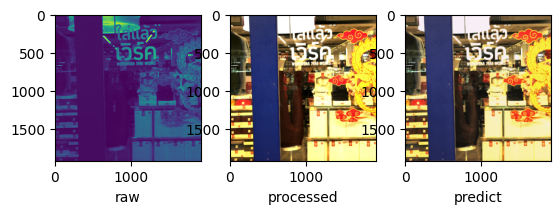

[02-26 20:22:25] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 1.600e+01 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.022s
Executing cfa... Done. Elapsed 0.124s
Executing ccm... Done. Elapsed 0.119s
Executing gac... Done. Elapsed 0.052s
Executing bnfcv... Done. Elapsed 0.077s
Executing csc... Done. Elapsed 0.168s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.143s
Executing bcc... Done. Elapsed 0.020s
Pipeline elapsed 0.996s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
16


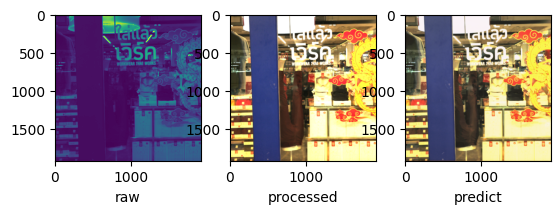

[02-26 20:22:27] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 3.300e+01 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.018s
Executing cfa... Done. Elapsed 0.122s
Executing ccm... Done. Elapsed 0.112s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.076s
Executing csc... Done. Elapsed 0.118s
Executing ceh... Done. Elapsed 0.070s
Executing eeh... Done. Elapsed 0.146s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 0.893s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
33


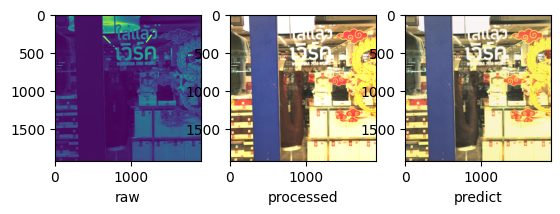

[02-26 20:22:28] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 5.000e+01 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.123s
Executing ccm... Done. Elapsed 0.125s
Executing gac... Done. Elapsed 0.054s
Executing bnfcv... Done. Elapsed 0.076s
Executing csc... Done. Elapsed 0.161s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.143s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 0.960s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
50


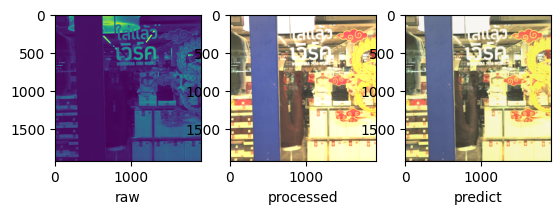

In [3]:
plot_sweeping_hyperp("bcc-brightness_offset", 4, 7)

[02-26 20:22:34] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 1.280e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.126s
Executing gac... Done. Elapsed 0.052s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.157s
Executing ceh... Done. Elapsed 0.070s
Executing eeh... Done. Elapsed 0.140s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 0.927s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
128


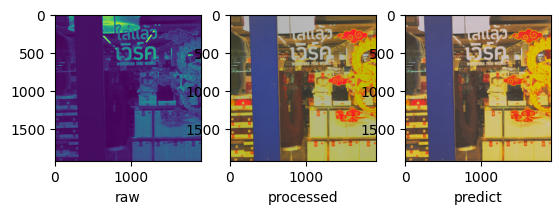

[02-26 20:22:36] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.020s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.114s
Executing gac... Done. Elapsed 0.054s
Executing bnfcv... Done. Elapsed 0.076s
Executing csc... Done. Elapsed 0.119s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.142s
Executing bcc... Done. Elapsed 0.020s
Pipeline elapsed 0.883s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
256


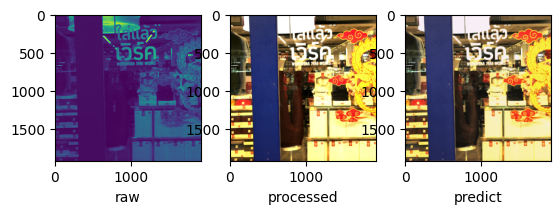

[02-26 20:22:38] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 3.840e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.017s
Executing cfa... Done. Elapsed 0.119s
Executing ccm... Done. Elapsed 0.117s
Executing gac... Done. Elapsed 0.052s
Executing bnfcv... Done. Elapsed 0.077s
Executing csc... Done. Elapsed 0.410s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.140s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.144s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
384


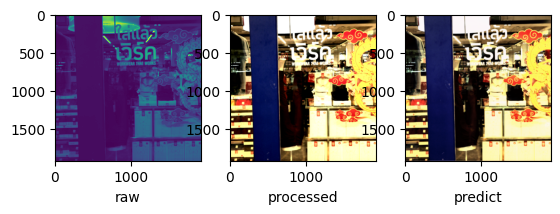

[02-26 20:22:40] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 5.120e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.014s
Executing cfa... Done. Elapsed 0.122s
Executing ccm... Done. Elapsed 0.117s
Executing gac... Done. Elapsed 0.054s
Executing bnfcv... Done. Elapsed 0.078s
Executing csc... Done. Elapsed 0.121s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.152s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 0.874s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
512


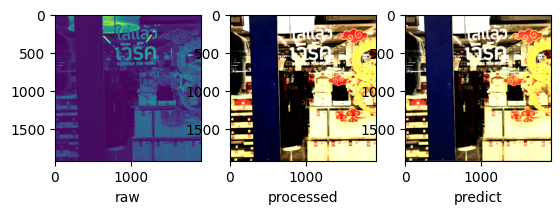

In [4]:
plot_sweeping_hyperp("bcc-contrast_gain", 4, 7)

[02-26 20:25:06] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 2.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.014s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.134s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.073s
Executing csc... Done. Elapsed 0.442s
Executing ceh... Done. Elapsed 0.062s
Executing eeh... Done. Elapsed 0.142s
Executing bcc... Done. Elapsed 0.020s
Pipeline elapsed 1.181s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
2


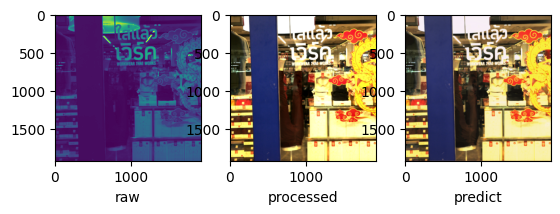

[02-26 20:25:08] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.117s
Executing ccm... Done. Elapsed 0.124s
Executing gac... Done. Elapsed 0.053s
Executing bnfcv... Done. Elapsed 0.072s
Executing csc... Done. Elapsed 0.450s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.144s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.185s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
4


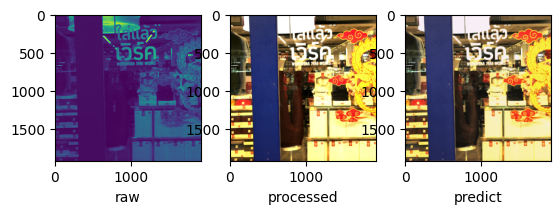

[02-26 20:25:10] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 7.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.119s
Executing ccm... Done. Elapsed 0.118s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.072s
Executing csc... Done. Elapsed 0.410s
Executing ceh... Done. Elapsed 0.072s
Executing eeh... Done. Elapsed 0.145s
Executing bcc... Done. Elapsed 0.023s
Pipeline elapsed 1.150s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
7


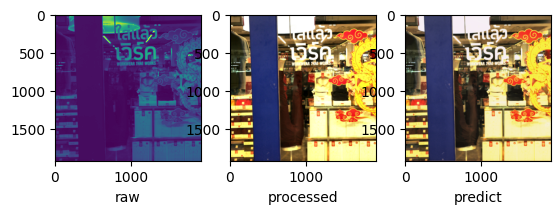

[02-26 20:25:13] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 1.000e+01
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.010s
Executing cfa... Done. Elapsed 0.109s
Executing ccm... Done. Elapsed 0.124s
Executing gac... Done. Elapsed 0.048s
Executing bnfcv... Done. Elapsed 0.067s
Executing csc... Done. Elapsed 0.131s
Executing ceh... Done. Elapsed 0.075s
Executing eeh... Done. Elapsed 0.126s
Executing bcc... Done. Elapsed 0.018s
Pipeline elapsed 0.872s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
10


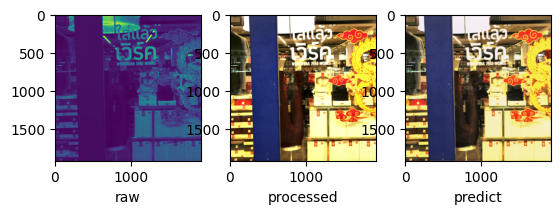

In [9]:
plot_sweeping_hyperp("ceh-tiles_0", 4, 7)

[02-26 20:25:35] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 1.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.110s
Executing ccm... Done. Elapsed 0.128s
Executing gac... Done. Elapsed 0.050s
Executing bnfcv... Done. Elapsed 0.068s
Executing csc... Done. Elapsed 0.128s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.132s
Executing bcc... Done. Elapsed 0.020s
Pipeline elapsed 0.876s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
0.01


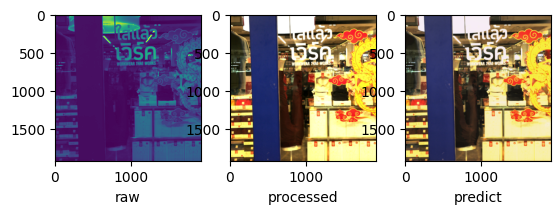

[02-26 20:25:37] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.00000000e+00 0.00000000e+00 1.02400000e+03 1.00000000e+00
 0.00000000e+00 2.56000000e+02 4.00000000e+00 6.00000000e+00
 1.73333333e-01 1.50000000e+01 1.00000000e+02 1.00000000e+02
 3.84000000e+02 4.00000000e+00 8.00000000e+00 6.40000000e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.111s
Executing ccm... Done. Elapsed 0.128s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.067s
Executing csc... Done. Elapsed 0.159s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.144s
Executing bcc... Done. Elapsed 0.019s
Pipeline elapsed 0.921s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
0.17333333333333334


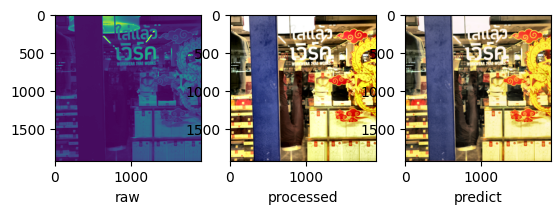

[02-26 20:25:39] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.00000000e+00 0.00000000e+00 1.02400000e+03 1.00000000e+00
 0.00000000e+00 2.56000000e+02 4.00000000e+00 6.00000000e+00
 3.36666667e-01 1.50000000e+01 1.00000000e+02 1.00000000e+02
 3.84000000e+02 4.00000000e+00 8.00000000e+00 6.40000000e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.013s
Executing cfa... Done. Elapsed 0.113s
Executing ccm... Done. Elapsed 0.145s
Executing gac... Done. Elapsed 0.052s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.461s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.147s
Executing bcc... Done. Elapsed 0.026s
Pipeline elapsed 1.264s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
0.33666666666666667


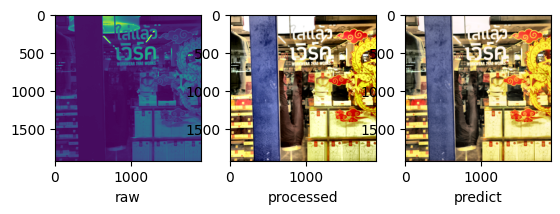

[02-26 20:25:41] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 5.000e-01 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.116s
Executing ccm... Done. Elapsed 0.120s
Executing gac... Done. Elapsed 0.053s
Executing bnfcv... Done. Elapsed 0.069s
Executing csc... Done. Elapsed 0.411s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.153s
Executing bcc... Done. Elapsed 0.026s
Pipeline elapsed 1.157s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
0.5


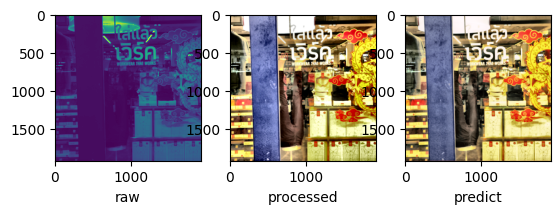

In [10]:
plot_sweeping_hyperp("ceh-clip_limit", 4, 7)


[02-26 20:26:09] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 5.000e+00 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.124s
Executing ccm... Done. Elapsed 0.130s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.006s
Executing csc... Done. Elapsed 0.120s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.148s
Executing bcc... Done. Elapsed 0.024s
Pipeline elapsed 0.841s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
5


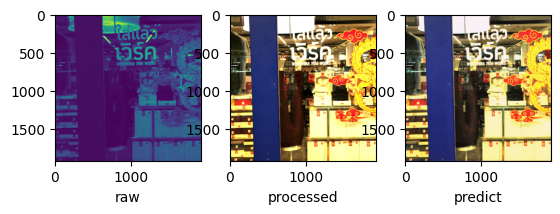

[02-26 20:26:11] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.300e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.121s
Executing ccm... Done. Elapsed 0.117s
Executing gac... Done. Elapsed 0.054s
Executing bnfcv... Done. Elapsed 0.050s
Executing csc... Done. Elapsed 0.412s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.147s
Executing bcc... Done. Elapsed 0.022s
Pipeline elapsed 1.126s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
13


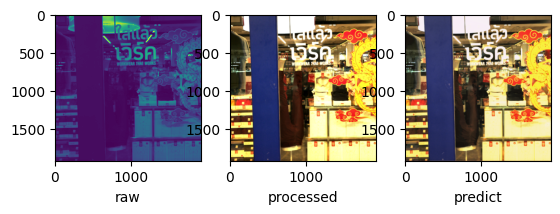

[02-26 20:26:13] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 2.100e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.124s
Executing ccm... Done. Elapsed 0.117s
Executing gac... Done. Elapsed 0.053s
Executing bnfcv... Done. Elapsed 0.210s
Executing csc... Done. Elapsed 0.410s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.138s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.600s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
21


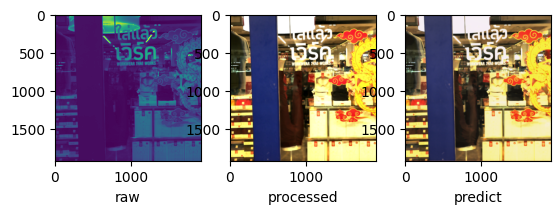

[02-26 20:26:15] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 3.000e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.121s
Executing ccm... Done. Elapsed 0.130s
Executing gac... Done. Elapsed 0.055s
Executing bnfcv... Done. Elapsed 0.447s
Executing csc... Done. Elapsed 0.460s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.151s
Executing bcc... Done. Elapsed 0.024s
Pipeline elapsed 1.637s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
30


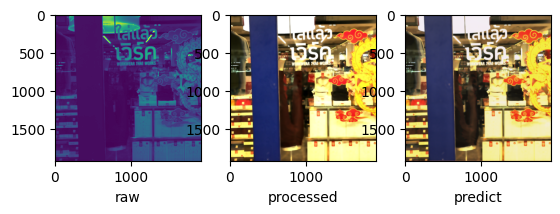

In [11]:
plot_sweeping_hyperp("bnfcv-d", 4, 7)

[02-26 20:26:37] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+01 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.120s
Executing ccm... Done. Elapsed 0.132s
Executing gac... Done. Elapsed 0.054s
Executing bnfcv... Done. Elapsed 0.067s
Executing csc... Done. Elapsed 0.459s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.148s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.248s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
10


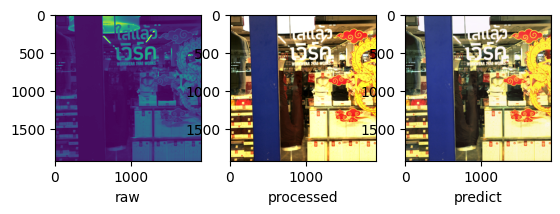

[02-26 20:26:39] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 4.000e+01 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.125s
Executing ccm... Done. Elapsed 0.169s
Executing gac... Done. Elapsed 0.061s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.466s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.152s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.321s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
40


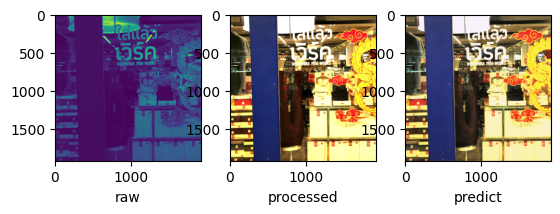

[02-26 20:26:41] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 7.000e+01 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.121s
Executing ccm... Done. Elapsed 0.130s
Executing gac... Done. Elapsed 0.059s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.418s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.149s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.175s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
70


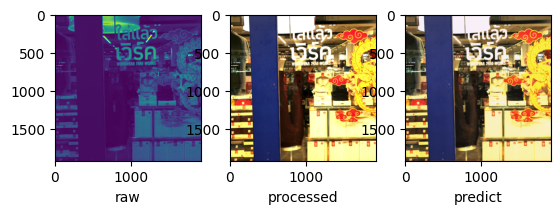

[02-26 20:26:43] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.014s
Executing cfa... Done. Elapsed 0.119s
Executing ccm... Done. Elapsed 0.129s
Executing gac... Done. Elapsed 0.056s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.093s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.152s
Executing bcc... Done. Elapsed 0.023s
Pipeline elapsed 0.852s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
100


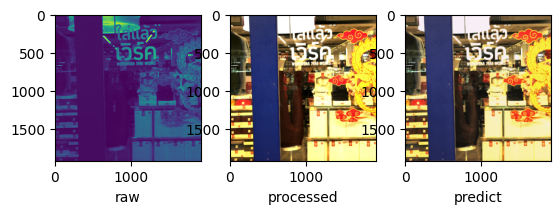

In [12]:
plot_sweeping_hyperp("bnfcv-sigma_color", 4, 7)

[02-26 20:27:08] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+01 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.122s
Executing ccm... Done. Elapsed 0.130s
Executing gac... Done. Elapsed 0.060s
Executing bnfcv... Done. Elapsed 0.068s
Executing csc... Done. Elapsed 0.122s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.162s
Executing bcc... Done. Elapsed 0.022s
Pipeline elapsed 0.897s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
10


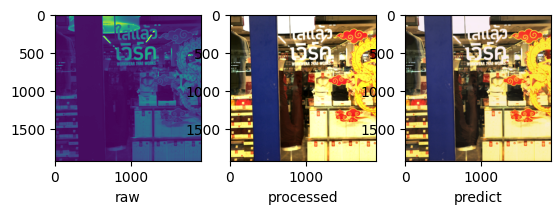

[02-26 20:27:10] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 4.000e+01 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.111s
Executing ccm... Done. Elapsed 0.099s
Executing gac... Done. Elapsed 0.039s
Executing bnfcv... Done. Elapsed 0.067s
Executing csc... Done. Elapsed 0.126s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.129s
Executing bcc... Done. Elapsed 0.018s
Pipeline elapsed 0.825s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
40


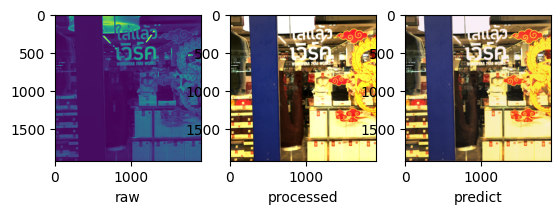

[02-26 20:27:12] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 7.000e+01 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.109s
Executing ccm... Done. Elapsed 0.111s
Executing gac... Done. Elapsed 0.042s
Executing bnfcv... Done. Elapsed 0.072s
Executing csc... Done. Elapsed 0.127s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.133s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 0.860s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
70


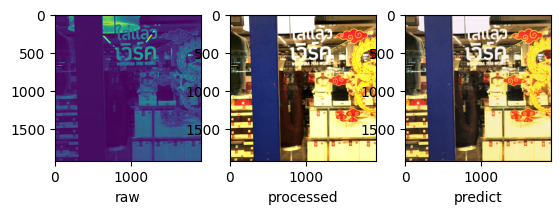

[02-26 20:27:13] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.116s
Executing ccm... Done. Elapsed 0.110s
Executing gac... Done. Elapsed 0.041s
Executing bnfcv... Done. Elapsed 0.065s
Executing csc... Done. Elapsed 0.081s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.128s
Executing bcc... Done. Elapsed 0.018s
Pipeline elapsed 0.755s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
100


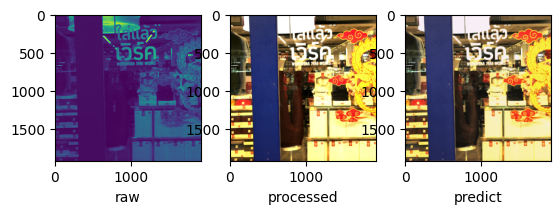

In [13]:
plot_sweeping_hyperp("bnfcv-sigma_space", 4, 7)

[02-26 20:27:49] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 0.000e+00 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.010s
Executing cfa... Done. Elapsed 0.115s
Executing ccm... Done. Elapsed 0.130s
Executing gac... Done. Elapsed 0.051s
Executing bnfcv... Done. Elapsed 0.068s
Executing csc... Done. Elapsed 0.136s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.129s
Executing bcc... Done. Elapsed 0.016s
Pipeline elapsed 0.897s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
0


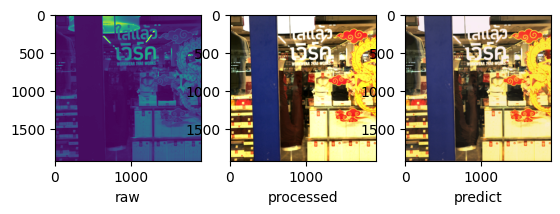

[02-26 20:27:51] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.330e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.116s
Executing ccm... Done. Elapsed 0.126s
Executing gac... Done. Elapsed 0.050s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.114s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.125s
Executing bcc... Done. Elapsed 0.019s
Pipeline elapsed 0.855s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
333


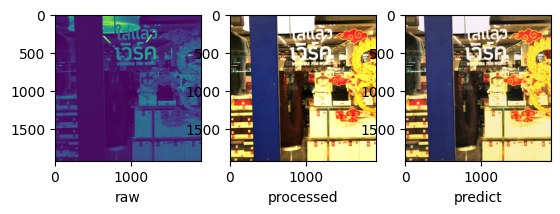

[02-26 20:27:52] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 6.660e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.117s
Executing ccm... Done. Elapsed 0.120s
Executing gac... Done. Elapsed 0.053s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.119s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.136s
Executing bcc... Done. Elapsed 0.024s
Pipeline elapsed 0.870s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
666


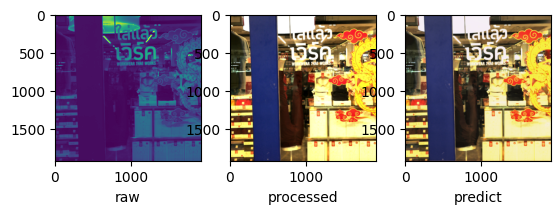

[02-26 20:27:54] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 1.000e+03 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.121s
Executing gac... Done. Elapsed 0.054s
Executing bnfcv... Done. Elapsed 0.065s
Executing csc... Done. Elapsed 0.409s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.132s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.446s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
1000


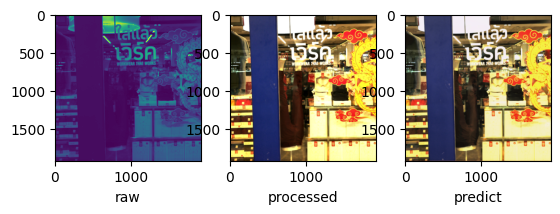

In [14]:
plot_sweeping_hyperp("eeh-edge_gain", 4, 7)

[02-26 20:28:25] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 1.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.115s
Executing gac... Done. Elapsed 0.052s
Executing bnfcv... Done. Elapsed 0.068s
Executing csc... Done. Elapsed 0.411s
Executing ceh... Done. Elapsed 0.067s
Executing eeh... Done. Elapsed 0.133s
Executing bcc... Done. Elapsed 0.022s
Pipeline elapsed 1.444s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
1


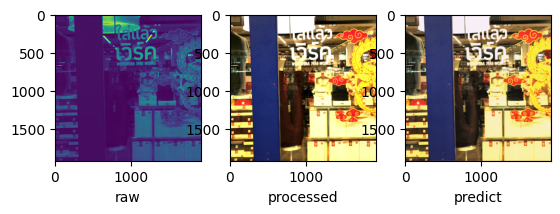

[02-26 20:28:27] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 4.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.113s
Executing ccm... Done. Elapsed 0.141s
Executing gac... Done. Elapsed 0.056s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.457s
Executing ceh... Done. Elapsed 0.068s
Executing eeh... Done. Elapsed 0.145s
Executing bcc... Done. Elapsed 0.021s
Pipeline elapsed 1.249s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
4


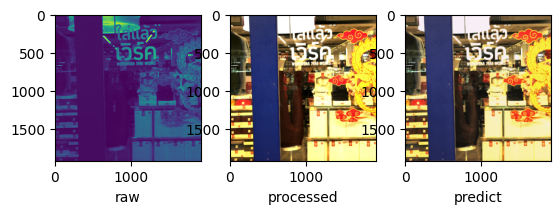

[02-26 20:28:29] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 7.000e+00
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.012s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... Done. Elapsed 0.116s
Executing gac... Done. Elapsed 0.053s
Executing bnfcv... Done. Elapsed 0.065s
Executing csc... Done. Elapsed 0.118s
Executing ceh... Done. Elapsed 0.069s
Executing eeh... Done. Elapsed 0.142s
Executing bcc... Done. Elapsed 0.018s
Pipeline elapsed 0.835s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
7


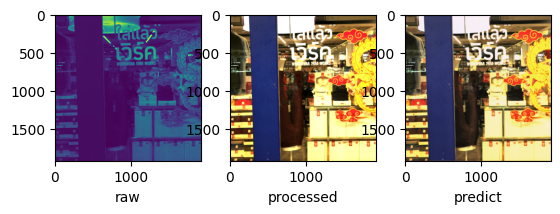

[02-26 20:28:31] ProxyISPDataset.py INFO - processing /home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng with hyp [1.000e+00 0.000e+00 1.024e+03 1.000e+00 0.000e+00 2.560e+02 4.000e+00
 6.000e+00 2.000e-02 1.500e+01 1.000e+02 1.000e+02 3.840e+02 1.000e+01
 8.000e+00 6.400e+01]


/home/boat/proxyISP/data/s21fe_dataset/20240115_164635.dng
Executing awb... Done. Elapsed 0.011s
Executing cfa... Done. Elapsed 0.118s
Executing ccm... 

/home/boat/proxyISP/ProxyOpt/../fast-openISP/modules/eeh.py:23: RuntimeWarning: invalid value encountered in cast
  self.middle_slope = np.array(self.params.edge_gain * t2 / threshold_delta, dtype=np.int32)  # x256


Done. Elapsed 0.120s
Executing gac... Done. Elapsed 0.052s
Executing bnfcv... Done. Elapsed 0.066s
Executing csc... Done. Elapsed 0.166s
Executing ceh... Done. Elapsed 0.070s
Executing eeh... Done. Elapsed 0.148s
Executing bcc... Done. Elapsed 0.022s
Pipeline elapsed 0.941s
raw torch.Size([1920, 1920])
raw torch.Size([4, 1920, 1920])
10


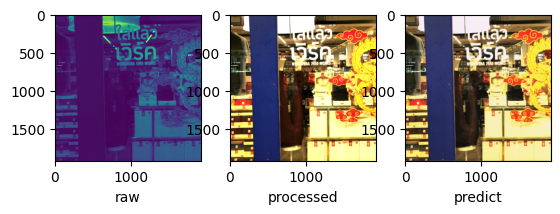

In [15]:
plot_sweeping_hyperp("eeh-flat_threshold", 4, 7)